### INTERPOLATION
We can use interpolation to generate a yield curve based on interest rates reported for different financial products of different maturities

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import bisect

In [24]:
zero_rates = pd.DataFrame(data=np.array([[0, 0.5],
                                         [2, 0.65],
                                         [6, 0.85],
                                         [12, 1.05],
                                         [20, 1.2]]), 
                        columns=['time', 'rate'])

zero_rates['time'] = zero_rates['time'] / 12  # Annualized
zero_rates['rate'] = zero_rates['rate'] / 100 # Decimal value

In [33]:
times = np.linspace(zero_rates['time'].values[0], zero_rates['time'].values[-1], 100)

# Step interpolation
step_interp = np.zeros(len(times))
for i,time in enumerate(times):
    idx = bisect.bisect_right(zero_rates['time'].values, time) - 1
    step_interp[i] = zero_rates['rate'][idx] * 100

# Linear interpolation
lin_interp = np.interp(times, zero_rates.time, zero_rates.rate * 100)

# Cubic spline interpolation 
cubicSpline = scipy.interpolate.CubicSpline(zero_rates.time, zero_rates.rate * 100)
cubic_interp = cubicSpline(times)

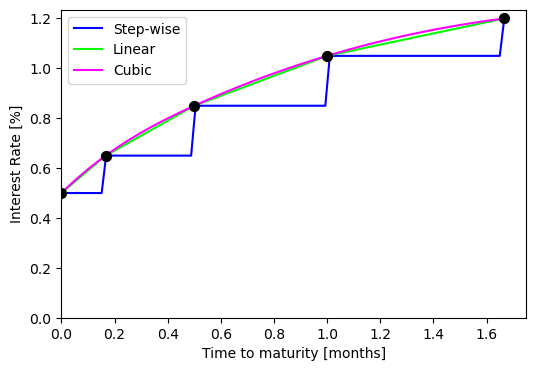

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(zero_rates.time, zero_rates.rate * 100, color='black', s=50, zorder=4)
ax.plot(times, step_interp, color='blue', label='Step-wise')
ax.plot(times, lin_interp, color='lime', label='Linear')
ax.plot(times, cubic_interp, color='magenta', label='Cubic')
ax.set_xlabel('Time to maturity [months]')
ax.set_ylabel('Interest Rate [%]')
ax.set_xlim(0, )
ax.set_ylim(0, )
ax.legend()
plt.show()